In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,5)

In [4]:
from google.colab import files

uploaded = files.upload()

Saving DataCo_Cleaned.csv to DataCo_Cleaned.csv


In [5]:
df = pd.read_csv("DataCo_Cleaned.csv", encoding='latin1')

print(df.shape)

(161423, 53)


In [6]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,59405.0,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,59405.0,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
2,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,59405.0,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class
3,TRANSFER,6,4,18.580000,294.980011,Shipping canceled,0,73,Sporting Goods,Tonawanda,...,59405.0,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/19/2018 11:03,Standard Class
4,DEBIT,2,1,95.180000,288.420013,Late delivery,1,73,Sporting Goods,Caguas,...,59405.0,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 10:42,First Class


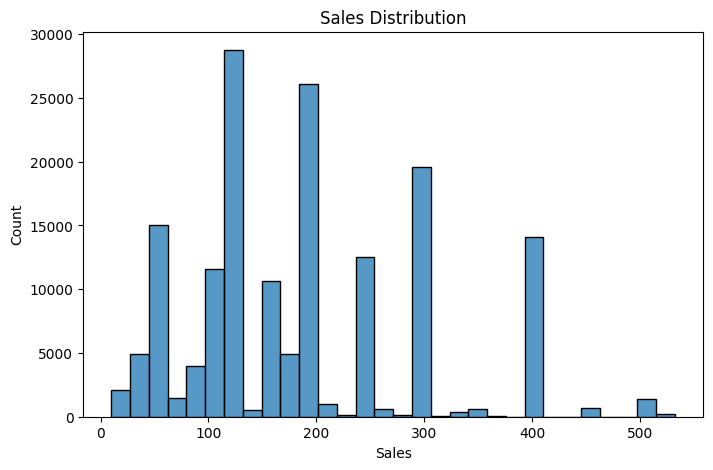

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.show()

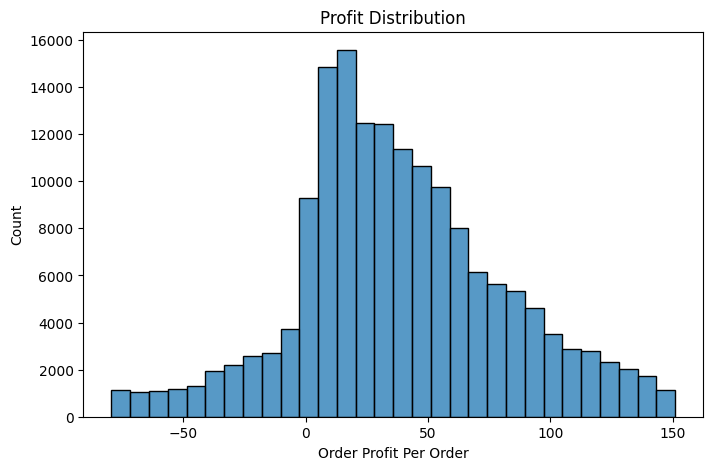

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Order Profit Per Order'], bins=30)

plt.title("Profit Distribution")
plt.show()

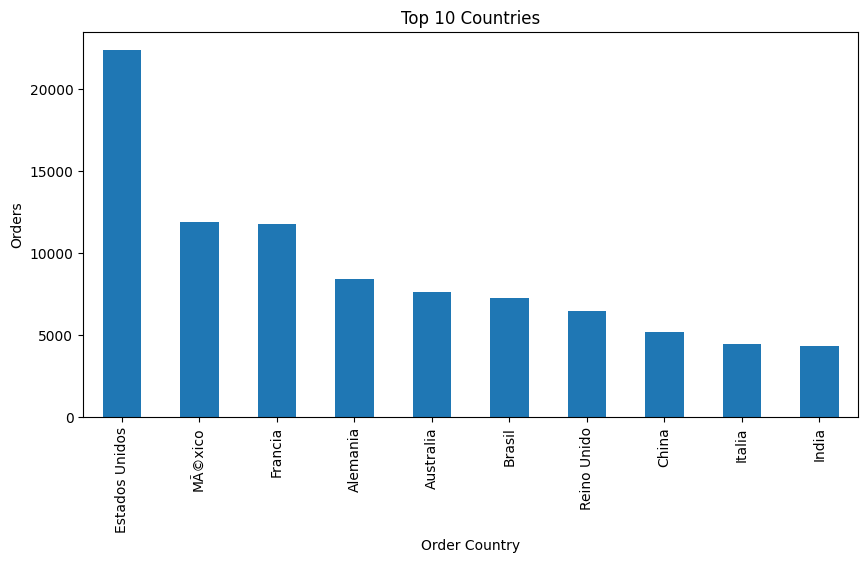

In [9]:
top_country = df['Order Country'].value_counts().head(10)

top_country.plot(kind='bar')

plt.title("Top 10 Countries")
plt.ylabel("Orders")
plt.show()

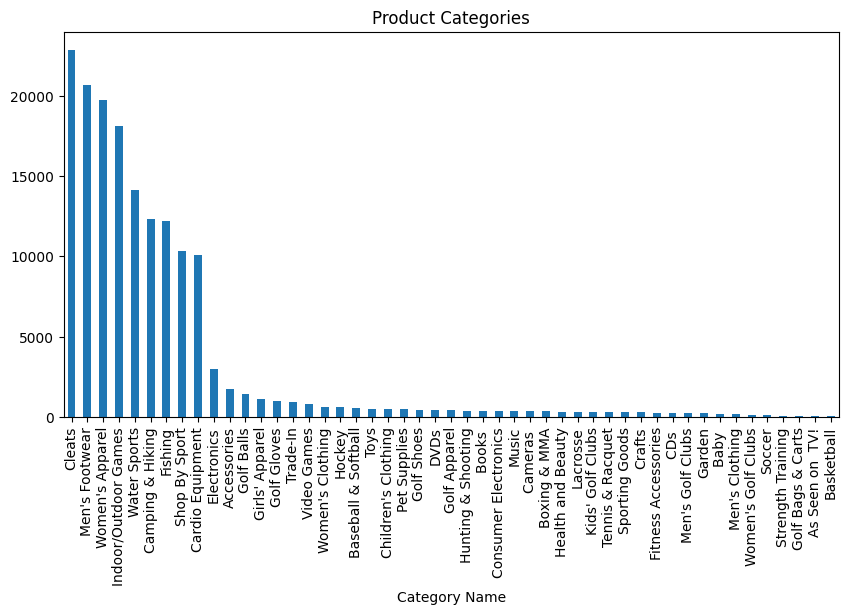

In [10]:
df['Category Name'].value_counts().plot(kind='bar')

plt.title("Product Categories")
plt.show()

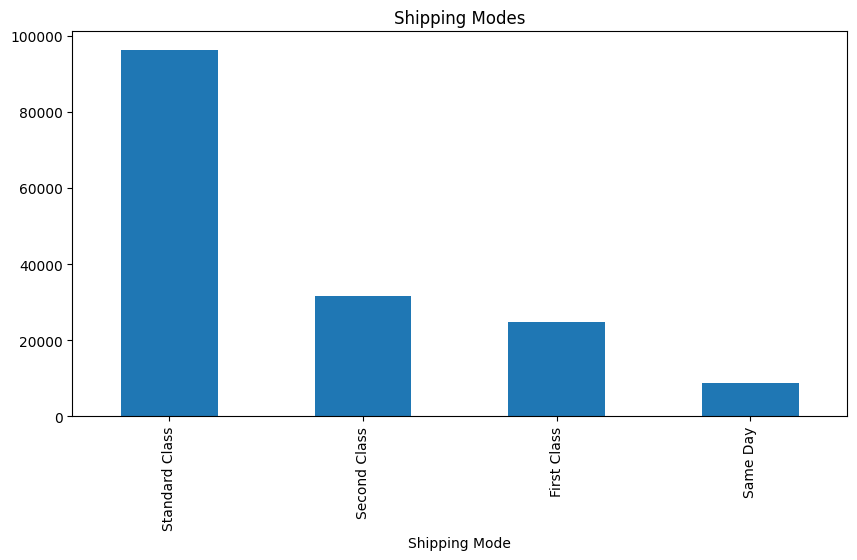

In [11]:
df['Shipping Mode'].value_counts().plot(kind='bar')

plt.title("Shipping Modes")
plt.show()

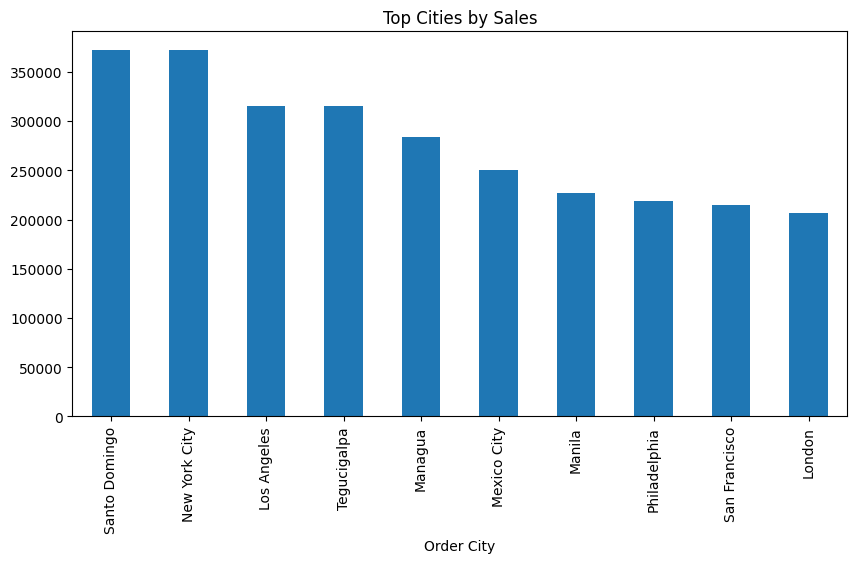

In [12]:
city_sales = df.groupby('Order City')['Sales'].sum()

city_sales.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Cities by Sales")
plt.show()

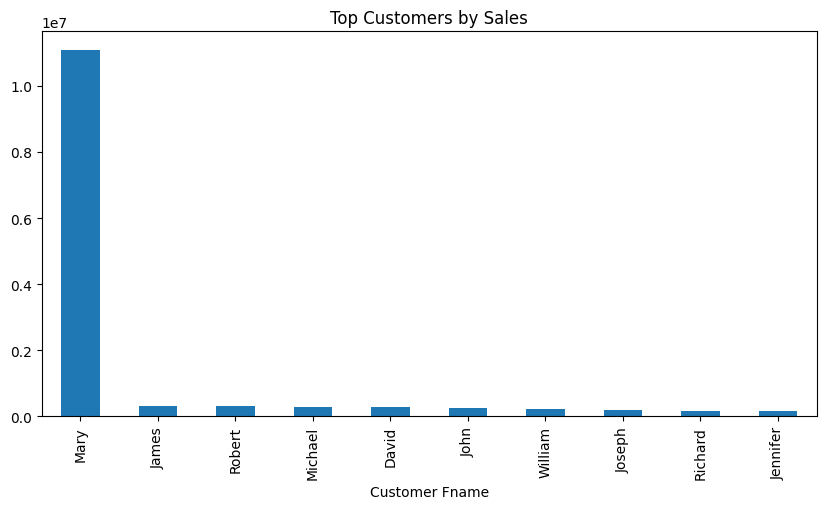

In [13]:
customer_sales = df.groupby(
    'Customer Fname'
)['Sales'].sum()

customer_sales.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top Customers by Sales")
plt.show()

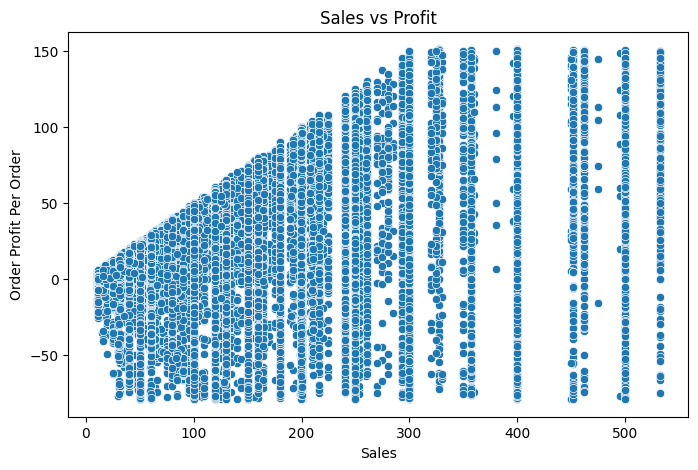

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Sales',
    y='Order Profit Per Order',
    data=df
)

plt.title("Sales vs Profit")
plt.show()


In [15]:
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)']
)

In [16]:
df['Month'] = df[
    'order date (DateOrders)'
].dt.month

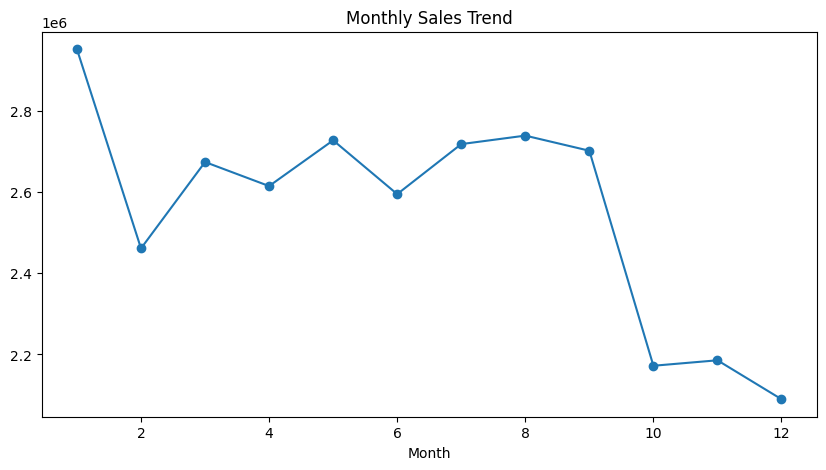

In [17]:
monthly_sales = df.groupby(
    'Month'
)['Sales'].sum()

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.show()

In [18]:
numeric_df = df.select_dtypes(
    include='number'
)

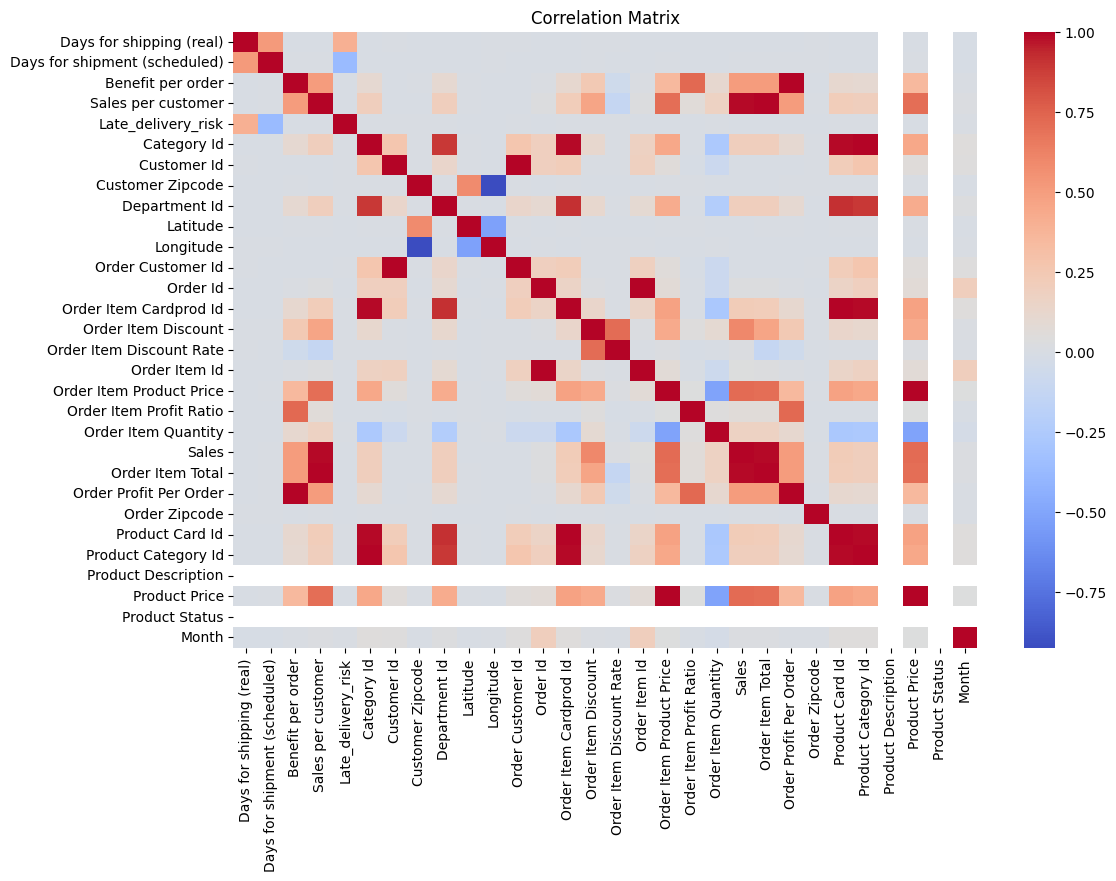

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

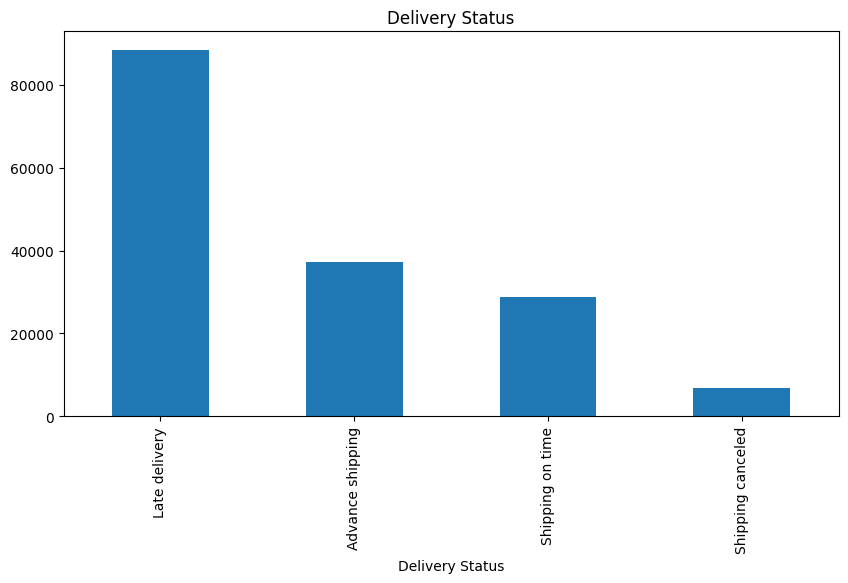

In [20]:
df['Delivery Status'].value_counts().plot(
    kind='bar'
)

plt.title("Delivery Status")
plt.show()

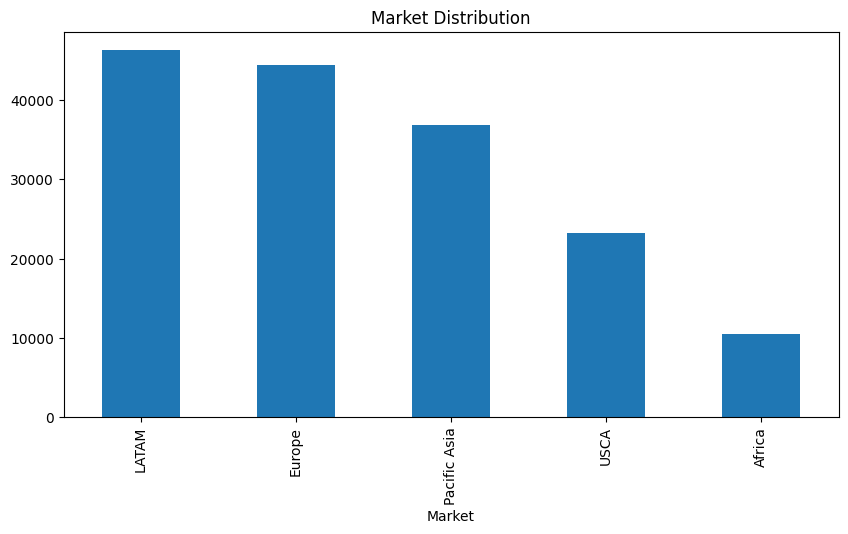

In [21]:
df['Market'].value_counts().plot(
    kind='bar'
)

plt.title("Market Distribution")
plt.show()

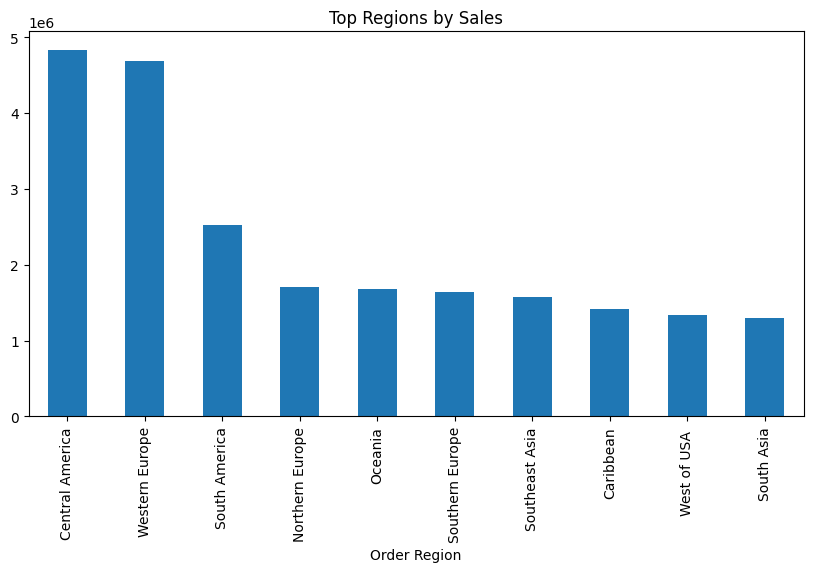

In [22]:
region_sales = df.groupby(
    'Order Region'
)['Sales'].sum()

region_sales.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Top Regions by Sales")
plt.show()

In [23]:
print("Total Orders :", len(df))

print("Total Sales :",
      round(df['Sales'].sum(),2))

print("Average Profit :",
      round(df['Order Profit Per Order'].mean(),2))

print("Top Market :",
      df['Market'].mode()[0])

print("Most Used Shipping Mode :",
      df['Shipping Mode'].mode()[0])

Total Orders : 161423
Total Sales : 30624103.22
Average Profit : 38.53
Top Market : LATAM
Most Used Shipping Mode : Standard Class


In [24]:
df.to_csv(
    "DataCo_EDA.csv",
    index=False
)

print("EDA Dataset Saved")

EDA Dataset Saved


In [25]:
from google.colab import files

files.download("DataCo_EDA.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>